# 3_pitchfork_test

Testing results from single pitchfork

In [1]:
#### misc
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product
from scipy import constants
from scipy import stats
import random
import astropy.constants
from numpy.random import default_rng

#### graphical
import matplotlib
import matplotlib.pyplot as plt

#### ML
import sklearn
from sklearn.decomposition import PCA
import tensorflow as tf
import keras
from keras import layers

#### custom
from InversePCA import InversePCA
from WMSE import WMSE, WMSE_metric

##### poke gpu
os.environ["CUDA_VISIBLE_DEVICES"]="0"

physical_devices = tf.config.list_physical_devices("GPU") 

gpu0usage = tf.config.experimental.get_memory_info("GPU:0")["current"]

print("Current GPU usage:\n"
     + " - GPU0: " + str(gpu0usage) + "B\n")

2024-02-22 14:51:03.108935: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-22 14:51:03.108965: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-22 14:51:03.109800: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-22 14:51:03.114451: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-02-22 14:51:03.657332: W tensorflow/compiler/tf2

Current GPU usage:
 - GPU0: 0B



2024-02-22 14:51:04.155384: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18008 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:41:00.0, compute capability: 8.6


## 1) load in grid
keep same routine as during training

In [2]:
def calc_Teff(luminosity, radius):
    return np.array(((luminosity.values*astropy.constants.L_sun) / (4*np.pi*constants.sigma*((radius.values*astropy.constants.R_sun)**2)))**0.25)

def rescale_preds(preds, df, column):
    if 'star_feh' in column:
        return (preds[column+"_std"]*df[column].std())+df[column].mean()
    else:
        return 10**((preds["log_"+column+"_std"]*df["log_"+column].std())+df["log_"+column].mean())

In [4]:
#### define inputs
inputs = ['log_initial_mass_std', 'log_initial_Zinit_std', 'log_initial_Yinit_std', 'log_initial_MLT_std', 'log_star_age_std']

#### define outputs
classical_outputs = ['log_radius_std', 'log_luminosity_std', 'log_surface_Z_std']
astero_outputs = ['log_nu_max_std', 'log_delta_nu_std']

pred_outputs = classical_outputs+astero_outputs

outputs = ['radius', 'luminosity', 'surface_Z', 'nu_max', 'delta_nu']

In [5]:
bob_df_full = pd.read_hdf('/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/keystone/bob.h5', key='df')

#### train/test split
seed = 42

df_train = bob_df_full.sample(frac=0.9, random_state=seed)
bob_df_test = bob_df_full.drop(df_train.index)

df_train_inputs, df_val_inputs, df_train_outputs, df_val_outputs = sklearn.model_selection.train_test_split(df_train[inputs],df_train[outputs], test_size = 0.1, random_state=seed)

pitchfork_name = "bob1"
pitchfork = tf.keras.models.load_model("/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/models/keystone/" + pitchfork_name + ".h5")

preds = pitchfork(np.array(bob_df_test[inputs]))

bob_preds_df = pd.DataFrame(np.concatenate((np.array(preds[0]),np.array(preds[1])), axis=1), columns=pred_outputs)

for output in outputs:
    bob_preds_df[output] = rescale_preds(bob_preds_df, bob_df_full, output)

bob_preds_df['effective_T'] = calc_Teff(bob_preds_df["luminosity"],bob_preds_df["radius"])

bob_errors_df=pd.DataFrame(np.array(bob_df_test[outputs+['effective_T']]) - np.array(bob_preds_df[outputs+['effective_T']]), columns=[outputs+['effective_T']])

2024-02-22 14:51:11.413952: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2024-02-22 14:51:11.472599: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904


In [6]:
barbie_df_full = pd.read_hdf('/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/keystone/barbie.h5', key='df')

#### train/test split
seed = 42

df_train = barbie_df_full.sample(frac=0.9, random_state=seed)
barbie_df_test = barbie_df_full.drop(df_train.index)

df_train_inputs, df_val_inputs, df_train_outputs, df_val_outputs = sklearn.model_selection.train_test_split(df_train[inputs],df_train[outputs], test_size = 0.1, random_state=seed)

pitchfork_name = "barbie1"
pitchfork = tf.keras.models.load_model("/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/models/keystone/" + pitchfork_name + ".h5")

preds = pitchfork(np.array(barbie_df_test[inputs]))

barbie_preds_df = pd.DataFrame(np.concatenate((np.array(preds[0]),np.array(preds[1])), axis=1), columns=pred_outputs)

for output in outputs:
    barbie_preds_df[output] = rescale_preds(barbie_preds_df, barbie_df_full, output)

barbie_preds_df['effective_T'] = calc_Teff(barbie_preds_df["luminosity"],barbie_preds_df["radius"])

barbie_errors_df=pd.DataFrame(np.array(barbie_df_test[outputs+['effective_T']]) - np.array(barbie_preds_df[outputs+['effective_T']]), columns=[outputs+['effective_T']])

bob radius MAD: [0.00220327]
barbie radius MAD: [0.00063489]
bob luminosity MAD: [0.00692411]
barbie luminosity MAD: [0.00209376]
bob effective_T MAD: [6.93588948]
barbie effective_T MAD: [2.54618188]
bob surface_Z MAD: [4.0591697e-05]
barbie surface_Z MAD: [2.85273329e-05]
bob delta_nu MAD: [0.15149914]
barbie delta_nu MAD: [0.07026176]
bob nu_max MAD: [3.87930204]
barbie nu_max MAD: [2.06523303]


Text(0.5, 0, '$\\mu Hz$')

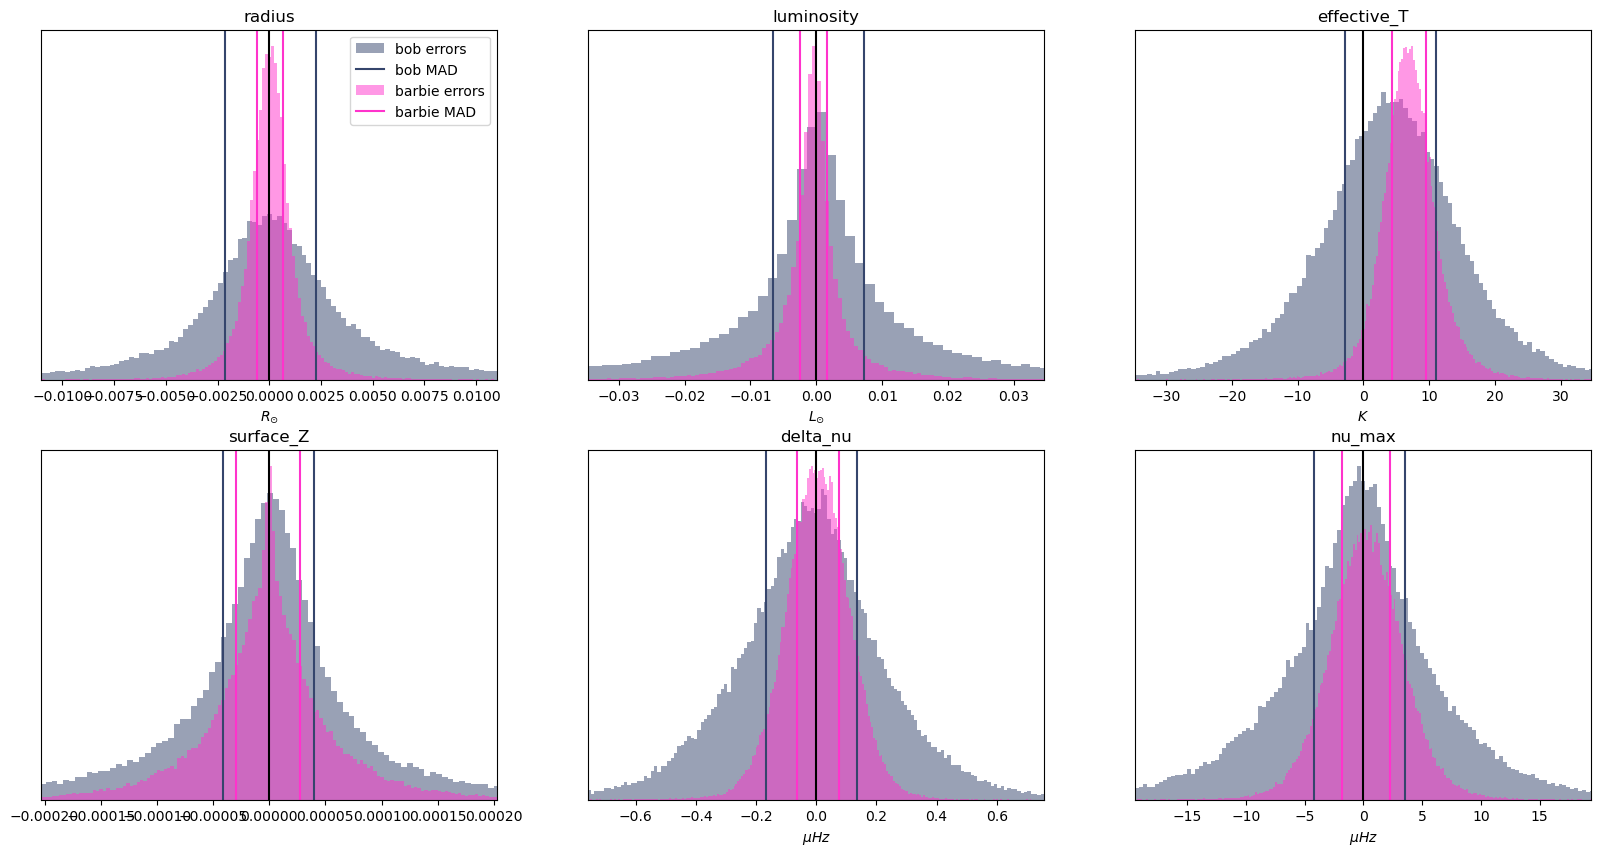

In [19]:

def output_plot(bob_errors_df, barbie_errors_df, output, axis):
    bob_errors = bob_errors_df[output]
    bob_errors_mad = stats.median_abs_deviation(bob_errors)
    bob_errors_med = np.median(bob_errors)
    axis.hist(bob_errors, bins=500, color=matplotlib.colormaps.get_cmap('cividis')(0.2), alpha=0.5, label='bob errors')
    axis.axvline(bob_errors_med + bob_errors_mad, color=matplotlib.colormaps.get_cmap('cividis')(0.2), label='bob MAD')
    axis.axvline(bob_errors_med - bob_errors_mad, color=matplotlib.colormaps.get_cmap('cividis')(0.2))
    print("bob " +output + " MAD: " + str(bob_errors_mad))

    barbie_errors = barbie_errors_df[output]
    barbie_errors_mad = stats.median_abs_deviation(barbie_errors)
    barbie_errors_med = np.median(barbie_errors)
    axis.hist(barbie_errors, bins=500, color=matplotlib.colormaps.get_cmap('spring')(0.2), alpha=0.5, label='barbie errors')
    axis.axvline(barbie_errors_med + barbie_errors_mad, color=matplotlib.colormaps.get_cmap('spring')(0.2), label='barbie MAD')
    axis.axvline(barbie_errors_med - barbie_errors_mad, color=matplotlib.colormaps.get_cmap('spring')(0.2))
    print("barbie " +output + " MAD: " + str(barbie_errors_mad))
    if output == 'radius':
        axis.legend()
    
    x_max = np.array([bob_errors_mad, barbie_errors_mad]).max()
    axis.set_xlim(xmin=-5*x_max, xmax=5*x_max)
    
    axis.axvline(0, color='black')
    axis.set_title(output)
    axis.set_yticks([])



fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(20,10))


output_plot(bob_errors_df, barbie_errors_df, 'radius', ax1)
ax1.set_xlabel('$R_{\odot}$')

output_plot(bob_errors_df, barbie_errors_df, 'luminosity', ax2)
ax2.set_xlabel('$L_{\odot}$')

output_plot(bob_errors_df, barbie_errors_df, 'effective_T', ax3)
ax3.set_xlabel('$K$')

output_plot(bob_errors_df, barbie_errors_df, 'surface_Z', ax4)
ax4.set_xlabel('')

output_plot(bob_errors_df, barbie_errors_df, 'delta_nu', ax5)
ax5.set_xlabel('$\mu Hz$')

output_plot(bob_errors_df, barbie_errors_df, 'nu_max', ax6)
ax6.set_xlabel('$\mu Hz$')